This shows the distibution of FiLM parameters , features before and after applying filM when the initial image is passed throught the image backbone EfficientNet followed by 4 FiLMed Resblock each consist of FiLM 


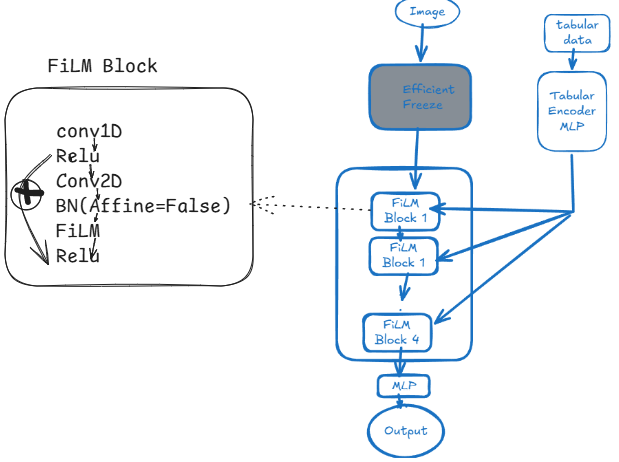

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
sys.path.insert(0, os.path.abspath("../../.."))

In [3]:
import os, time, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

gc.enable()
import torch

from src.config import EXP_CONFIGS
from src.utils import set_seed, save_config

main_folder = "../../.."
data_csv    = os.path.join(main_folder, "data", "train.csv")
img_folder  = os.path.join(main_folder, "data", "train")

# EXPERIMENT-SPECIFIC
cfg_key  = "exp12_film"  # or other key
exp_name = "exp12_film_fusion_EfficientNetB1_ExternalModulation_FreezeBackbone"
out_dir  = os.path.join(main_folder, "outputs", "extra", "exp12_film_fusion_EfficientNetB1_ExternalModulation_FreezeBackbone")

df  = pd.read_csv(data_csv)
TARGET   = "Pawpularity"
tab_cols = [c for c in df.columns if c not in ["Id", TARGET]]

cfg = EXP_CONFIGS[cfg_key].copy()
cfg["name"] = exp_name

os.makedirs(out_dir, exist_ok=True)
save_config(cfg, out_dir)
set_seed(cfg["seed"])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Experiment:", cfg["name"])
print("Out dir:", out_dir)

Device: cuda
Experiment: exp12_film_fusion_EfficientNetB1_ExternalModulation_FreezeBackbone
Out dir: ../../../outputs/extra/exp12_film_fusion_EfficientNetB1_ExternalModulation_FreezeBackbone


In [4]:
oof_path = os.path.join(out_dir, "oof_detail.csv")
df_oof   = pd.read_csv(oof_path)

fold_rmse_list = []
for f in range(1, cfg["n_splits"] + 1):
    sub  = df_oof[df_oof.fold == f]
    rmse = ((sub.ytrue - sub.oof_pred) ** 2).mean() ** 0.5
    fold_rmse_list.append((f, rmse))
    print(f"Fold {f} OOF RMSE: {rmse:.4f} (n={len(sub)})")

best_fold, best_rmse = min(fold_rmse_list, key=lambda x: x[1])
print(f"\nBest fold: {best_fold} (OOF RMSE={best_rmse:.4f})")

Fold 1 OOF RMSE: 20.6627 (n=1983)
Fold 2 OOF RMSE: 19.8652 (n=1983)
Fold 3 OOF RMSE: 19.3833 (n=1982)
Fold 4 OOF RMSE: 20.3258 (n=1982)
Fold 5 OOF RMSE: 20.2757 (n=1982)

Best fold: 3 (OOF RMSE=19.3833)


In [5]:
from sklearn.model_selection import KFold
from torch.utils.data import DataLoader
from src.data import build_transforms, ImageTabDataset

kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
splits = list(kf.split(df))
tr_idx, val_idx = splits[best_fold - 1]

val_df = df.iloc[val_idx].reset_index(drop=True)
val_tf = build_transforms(cfg["img_size"], cfg["aug"], train=False)
val_ds = ImageTabDataset(val_df, img_folder, tab_cols, val_tf)

val_loader = DataLoader(
    val_ds, batch_size=32, shuffle=False,
    num_workers=16, pin_memory=True,
)

print("Val size (best fold):", len(val_ds))

Val size (best fold): 1982


In [6]:
from src.film import FiLMExternalModulation

def build_best_model_external(cfg, tab_cols, best_fold, out_dir, device):
    model = FiLMExternalModulation(
        backbone_name        = cfg["backbone"],   # "efficientnet_b1" "
        tab_input_dim        = len(tab_cols),
        tab_hidden           = 64,                # match training (checkpoint)
        num_film_blocks      = 4,                 # same as training
        pretrained_backbone  = False,             # weights come from checkpoint
        freeze_backbone      = False,
        tab_encoder_capacity = "small",           
    )

    ckpt_path = os.path.join(out_dir, f"model_fold{best_fold}.pt")
    state = torch.load(ckpt_path, map_location="cpu")
    model.load_state_dict(state, strict=True)
    model.to(device).eval()
    print("Loaded:", ckpt_path)
    return model
analysis_model = build_best_model_external(cfg, tab_cols, best_fold, out_dir, device)

/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded: ../../../outputs/extra/exp12_film_fusion_EfficientNetB1_ExternalModulation_FreezeBackbone/model_fold3.pt


In [7]:
from src.film_analysis import collect_film_stats

gamma, beta, feat_before, feat_after = collect_film_stats(
    analysis_model, val_loader, device, max_batches=None
)
print("FiLM blocks found:", sorted(gamma.keys()))

FiLM blocks found: [0, 1, 2, 3]


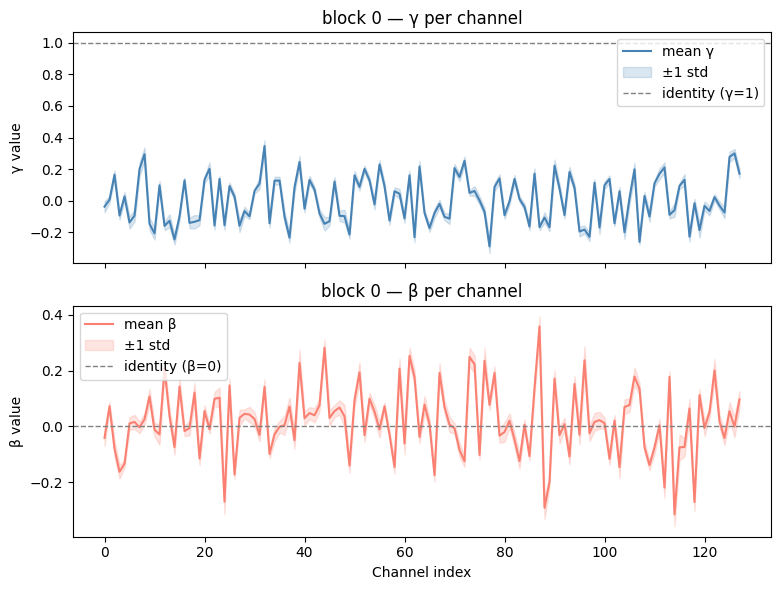

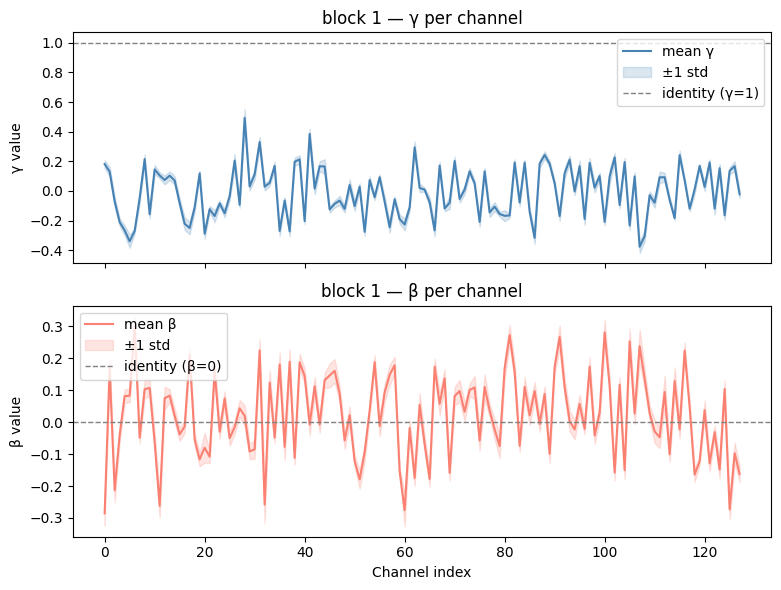

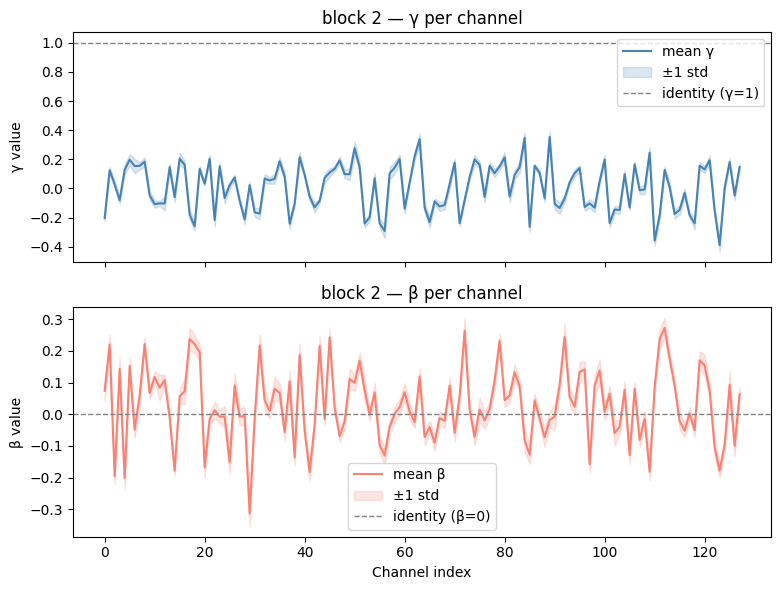

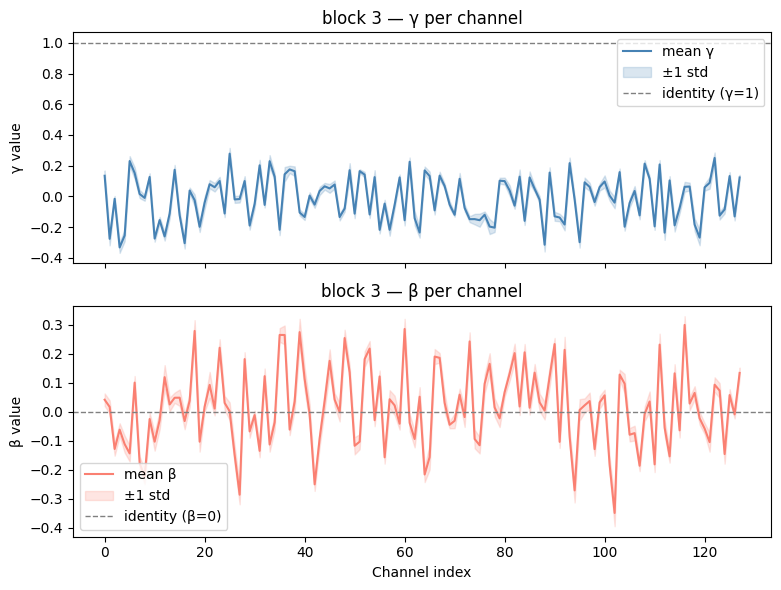

In [8]:
from src.film_analysis import plot_gamma_beta_per_channel

plot_gamma_beta_per_channel(
    gamma   = gamma,
    beta    = beta,
    exp_name = cfg["name"],
    out_dir  = out_dir,
)


[FiLM] Block 0  — exp12_film_fusion_EfficientNetB1_ExternalModulation_FreezeBackbone
  gamma shape:       (1982, 128)
  beta shape:        (1982, 128)
  feat_before shape: (1982, 128, 14, 14)
  feat_after shape:  (1982, 128, 14, 14)


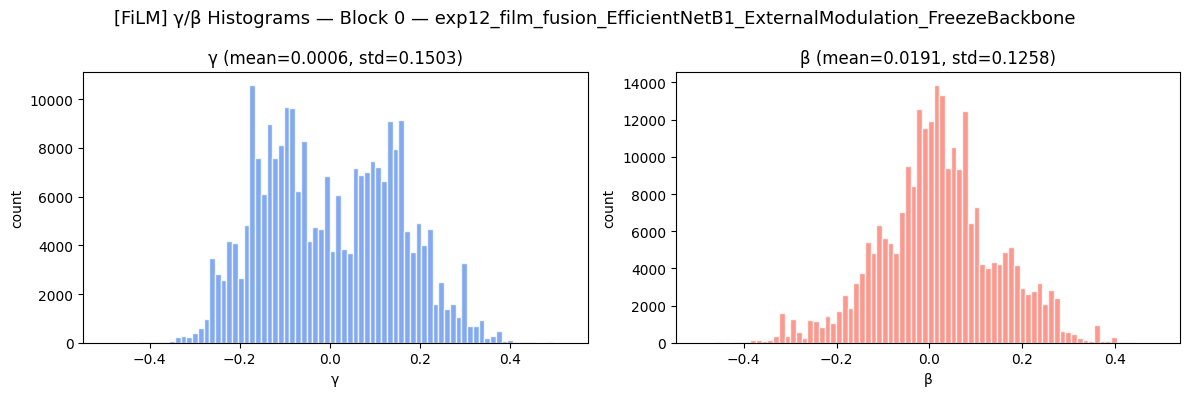

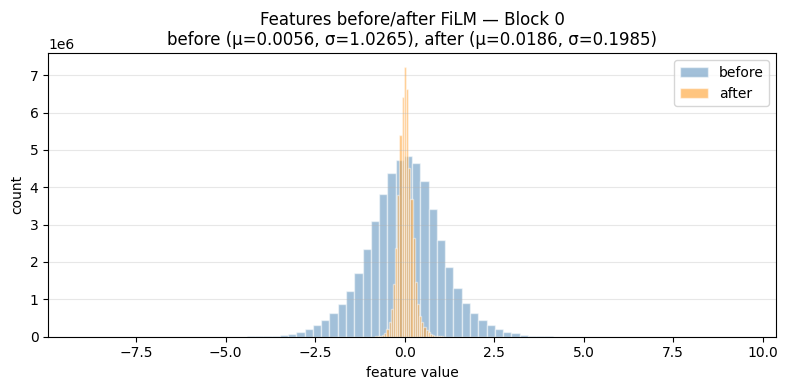

,block_idx,sample_idx,channel,h,w,before,after,gamma,beta,abs_diff
0,0,0,0,0,0,1.413892,-0.145941,-0.059014,-0.062502,1.559833
1,0,0,0,0,1,1.419579,-0.146277,-0.059014,-0.062502,1.565856
2,0,0,0,0,2,1.631729,-0.158797,-0.059014,-0.062502,1.790526
3,0,0,0,0,3,1.673146,-0.161241,-0.059014,-0.062502,1.834387
4,0,0,0,0,4,1.691125,-0.162302,-0.059014,-0.062502,1.853426
...,...,...,...,...,...,...,...,...,...,...
16380,0,0,83,8,0,-0.369738,-0.127798,-0.003483,-0.129085,0.241941
16381,0,0,83,8,1,0.476704,-0.130746,-0.003483,-0.129085,0.607450
16382,0,0,83,8,2,1.070457,-0.132814,-0.003483,-0.129085,1.203271
16383,0,0,83,8,3,0.938668,-0.132355,-0.003483,-0.129085,1.071023


[FiLM] Block 0 global stats:
  L2 ||after - before|| = 7360.1396


,block_idx,which,min,max,mean,std
0,0,before,-9.033347,9.452707,0.005647,1.026499
1,0,after,-2.034852,2.843482,0.018638,0.198524



[FiLM] Block 1  — exp12_film_fusion_EfficientNetB1_ExternalModulation_FreezeBackbone
  gamma shape:       (1982, 128)
  beta shape:        (1982, 128)
  feat_before shape: (1982, 128, 14, 14)
  feat_after shape:  (1982, 128, 14, 14)


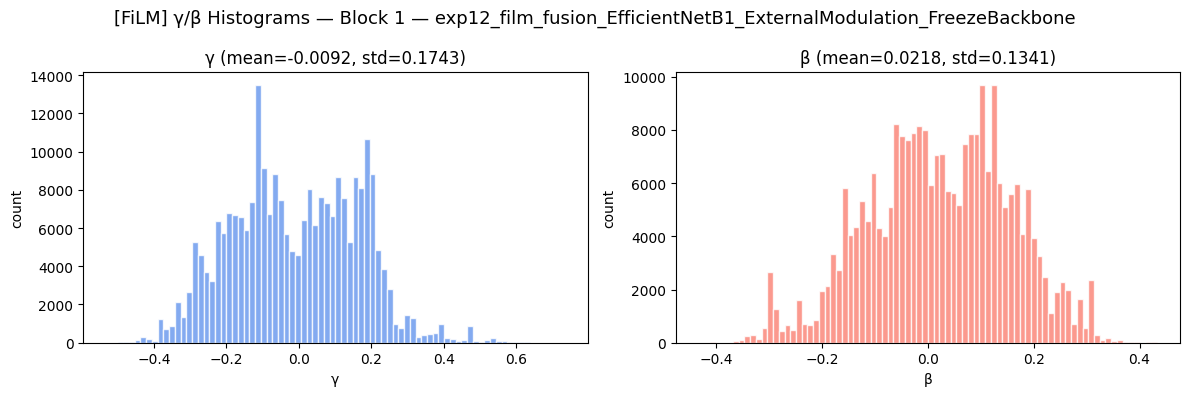

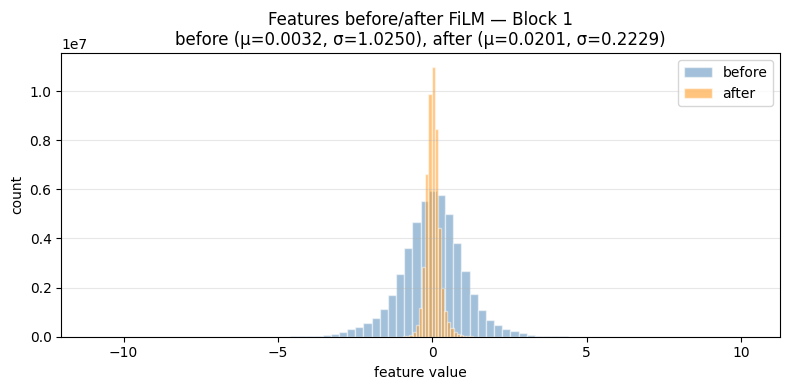

,block_idx,sample_idx,channel,h,w,before,after,gamma,beta,abs_diff
0,1,0,0,0,0,-0.699661,-0.457575,0.211270,-0.309757,0.242087
1,1,0,0,0,1,-0.349038,-0.383499,0.211270,-0.309757,0.034460
2,1,0,0,0,2,-0.458499,-0.406624,0.211270,-0.309757,0.051875
3,1,0,0,0,3,-0.578069,-0.431886,0.211270,-0.309757,0.146183
4,1,0,0,0,4,-0.850355,-0.489412,0.211270,-0.309757,0.360943
...,...,...,...,...,...,...,...,...,...,...
16380,1,0,83,8,0,0.431556,-0.106505,-0.094366,-0.065781,0.538061
16381,1,0,83,8,1,0.350721,-0.098877,-0.094366,-0.065781,0.449598
16382,1,0,83,8,2,0.268859,-0.091152,-0.094366,-0.065781,0.360011
16383,1,0,83,8,3,-0.046956,-0.061350,-0.094366,-0.065781,0.014394


[FiLM] Block 1 global stats:
  L2 ||after - before|| = 7457.8589


,block_idx,which,min,max,mean,std
0,1,before,-10.961978,10.209424,0.003173,1.024999
1,1,after,-3.400460,4.787256,0.020059,0.222945



[FiLM] Block 2  — exp12_film_fusion_EfficientNetB1_ExternalModulation_FreezeBackbone
  gamma shape:       (1982, 128)
  beta shape:        (1982, 128)
  feat_before shape: (1982, 128, 14, 14)
  feat_after shape:  (1982, 128, 14, 14)


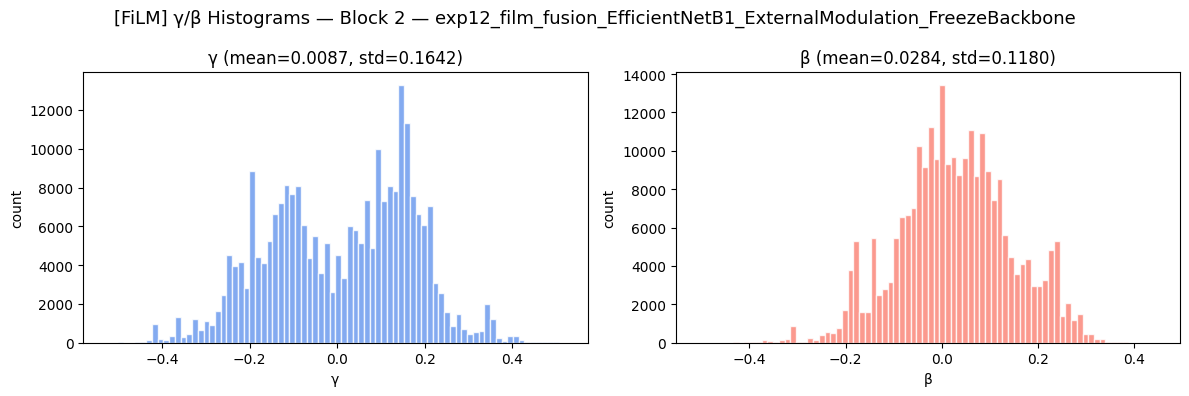

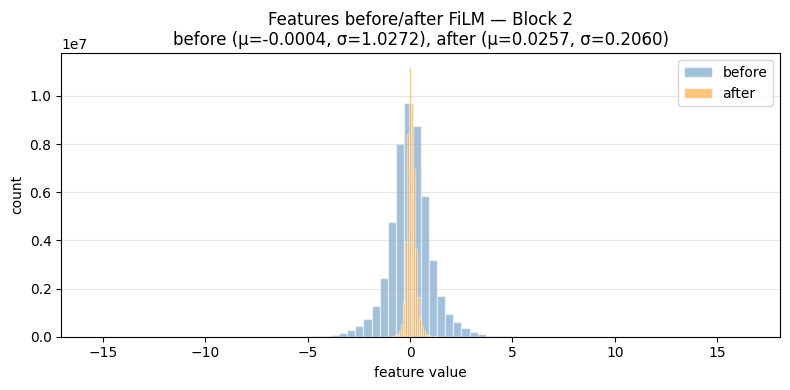

,block_idx,sample_idx,channel,h,w,before,after,gamma,beta,abs_diff
0,2,0,0,0,0,-0.937083,0.256216,-0.199794,0.068992,1.193299
1,2,0,0,0,1,-1.318151,0.332351,-0.199794,0.068992,1.650502
2,2,0,0,0,2,-1.712438,0.411127,-0.199794,0.068992,2.123564
3,2,0,0,0,3,-2.269609,0.522447,-0.199794,0.068992,2.792056
4,2,0,0,0,4,-2.663315,0.601107,-0.199794,0.068992,3.264422
...,...,...,...,...,...,...,...,...,...,...
16380,2,0,83,8,0,-1.568521,-0.199161,0.180068,0.083280,1.369359
16381,2,0,83,8,1,-0.187962,0.049433,0.180068,0.083280,0.237396
16382,2,0,83,8,2,0.187084,0.116967,0.180068,0.083280,0.070117
16383,2,0,83,8,3,0.461246,0.166335,0.180068,0.083280,0.294910


[FiLM] Block 2 global stats:
  L2 ||after - before|| = 7323.1782


,block_idx,which,min,max,mean,std
0,2,before,-15.441680,16.468975,-0.000405,1.027250
1,2,after,-3.107016,4.715930,0.025744,0.205995



[FiLM] Block 3  — exp12_film_fusion_EfficientNetB1_ExternalModulation_FreezeBackbone
  gamma shape:       (1982, 128)
  beta shape:        (1982, 128)
  feat_before shape: (1982, 128, 14, 14)
  feat_after shape:  (1982, 128, 14, 14)


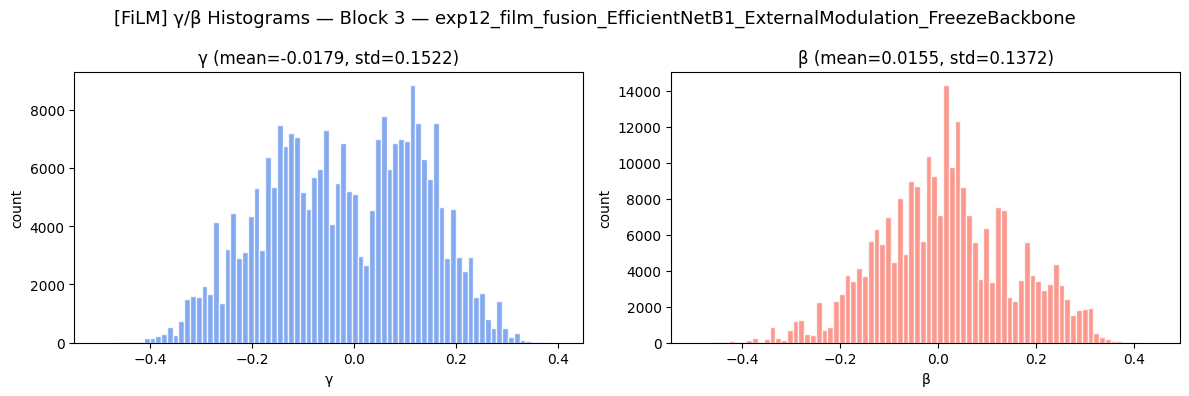

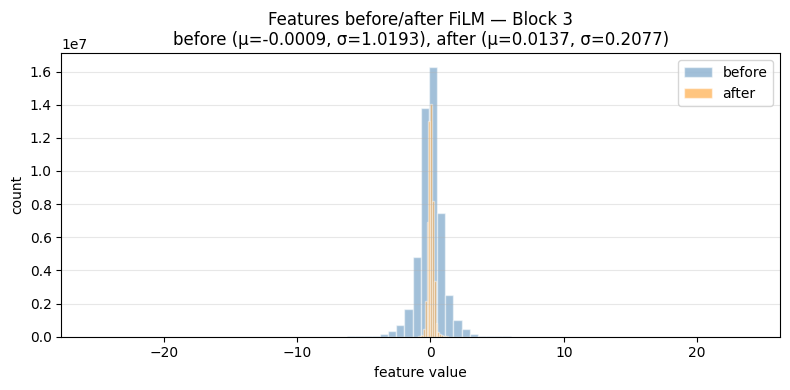

,block_idx,sample_idx,channel,h,w,before,after,gamma,beta,abs_diff
0,3,0,0,0,0,1.642123,0.193203,0.088328,0.048157,1.448920
1,3,0,0,0,1,2.340497,0.254889,0.088328,0.048157,2.085608
2,3,0,0,0,2,1.994623,0.224338,0.088328,0.048157,1.770285
3,3,0,0,0,3,2.548682,0.273277,0.088328,0.048157,2.275405
4,3,0,0,0,4,3.250609,0.335277,0.088328,0.048157,2.915332
...,...,...,...,...,...,...,...,...,...,...
16380,3,0,83,8,0,-0.962135,-0.076814,0.073929,-0.005684,0.885321
16381,3,0,83,8,1,-0.611821,-0.050916,0.073929,-0.005684,0.560906
16382,3,0,83,8,2,-0.427965,-0.037323,0.073929,-0.005684,0.390642
16383,3,0,83,8,3,-0.372642,-0.033233,0.073929,-0.005684,0.339409


[FiLM] Block 3 global stats:
  L2 ||after - before|| = 7451.2822


,block_idx,which,min,max,mean,std
0,3,before,-25.213594,23.757290,-0.000882,1.019279
1,3,after,-3.610445,7.051991,0.013721,0.207714


In [9]:
from src.film_analysis import analyze_film_per_block

analyze_film_per_block(
    gamma       = gamma,
    beta        = beta,
    feat_before = feat_before, #feature before FiLM 
    feat_after  = feat_after, # feature after FiLM 
    exp_name    = cfg["name"],
    out_dir     = out_dir,
    n_table_rows = 16385, 
)


[FiLM per-channel] Block 0 — exp12_film_fusion_EfficientNetB1_ExternalModulation_FreezeBackbone
  feat_before shape: (1982, 128, 14, 14)
  feat_after  shape: (1982, 128, 14, 14)


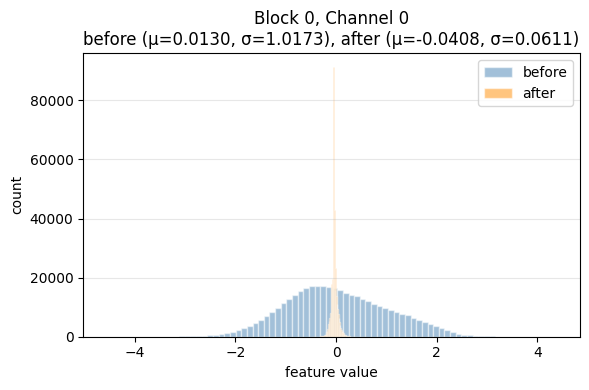

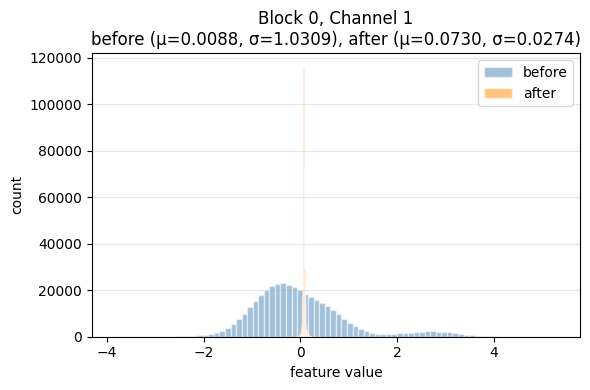

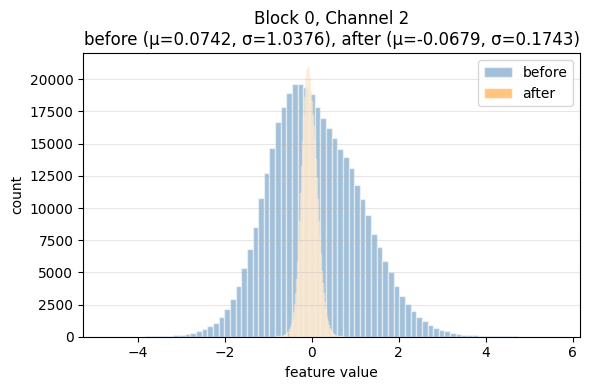

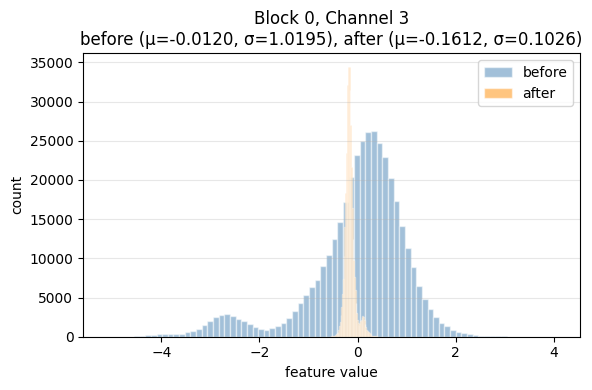


[FiLM per-channel] Block 1 — exp12_film_fusion_EfficientNetB1_ExternalModulation_FreezeBackbone
  feat_before shape: (1982, 128, 14, 14)
  feat_after  shape: (1982, 128, 14, 14)


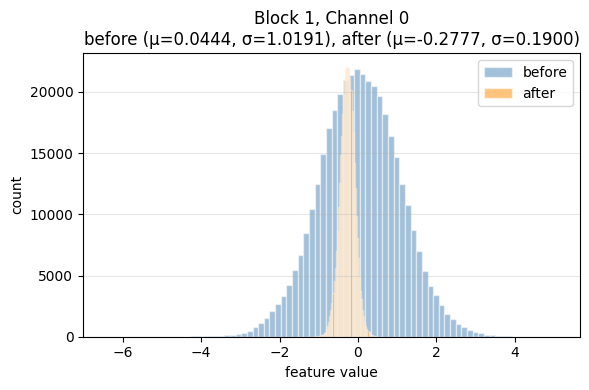

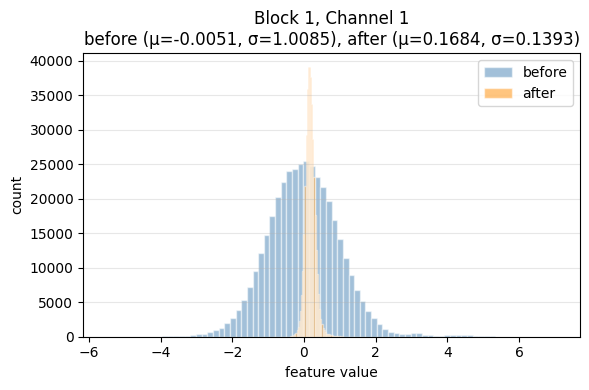

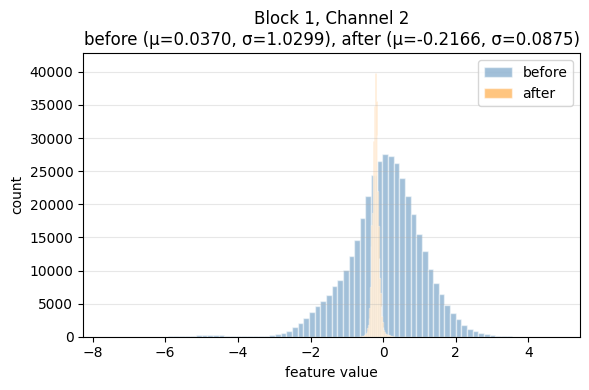

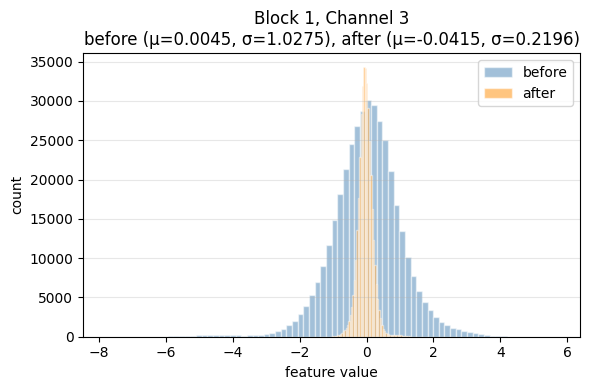


[FiLM per-channel] Block 2 — exp12_film_fusion_EfficientNetB1_ExternalModulation_FreezeBackbone
  feat_before shape: (1982, 128, 14, 14)
  feat_after  shape: (1982, 128, 14, 14)


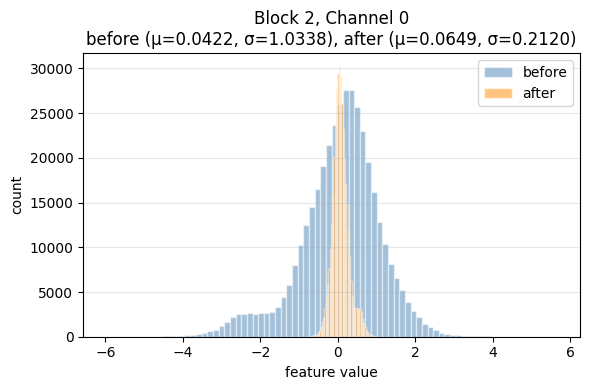

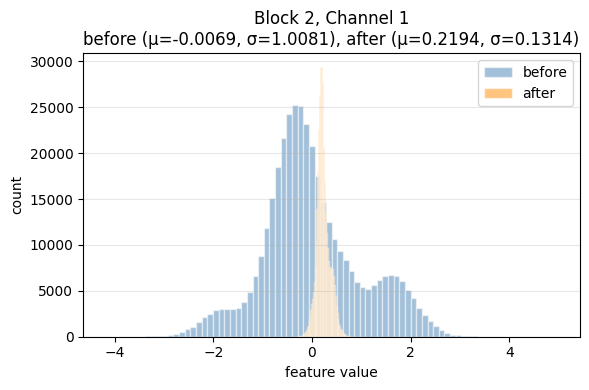

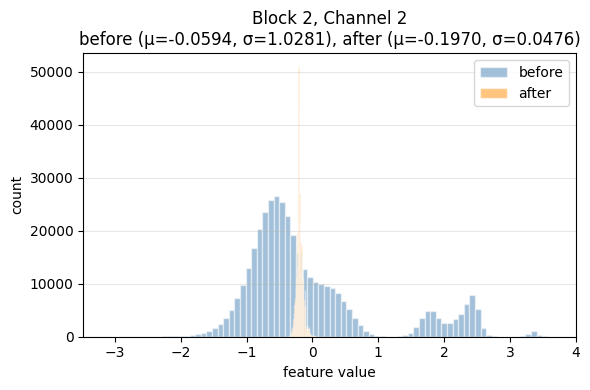

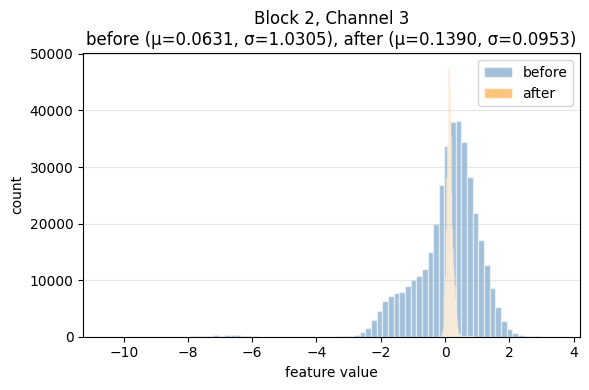


[FiLM per-channel] Block 3 — exp12_film_fusion_EfficientNetB1_ExternalModulation_FreezeBackbone
  feat_before shape: (1982, 128, 14, 14)
  feat_after  shape: (1982, 128, 14, 14)


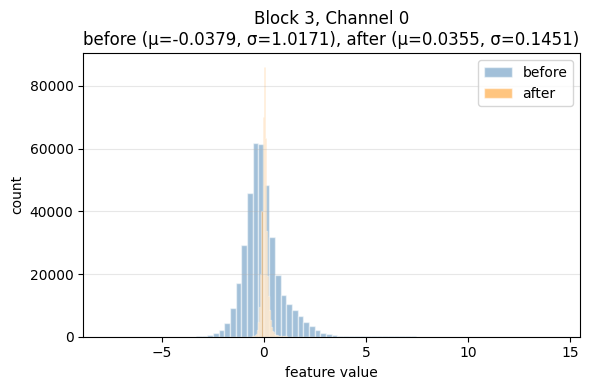

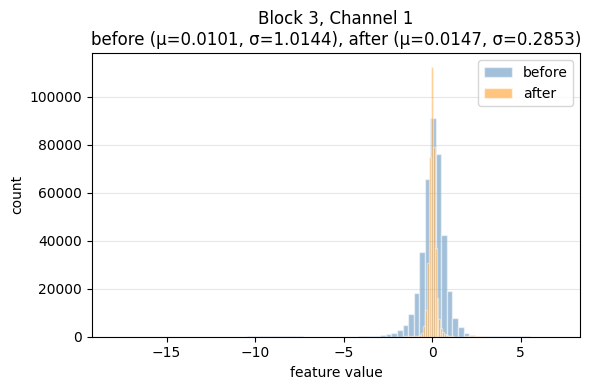

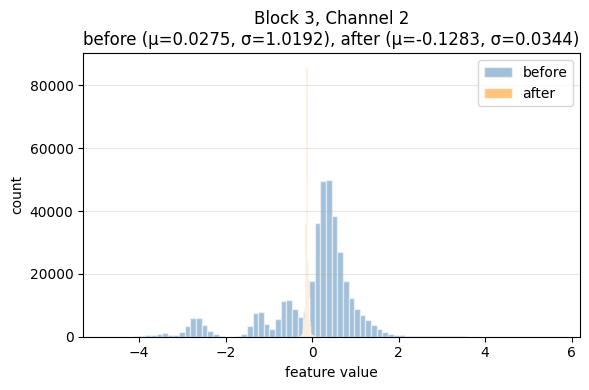

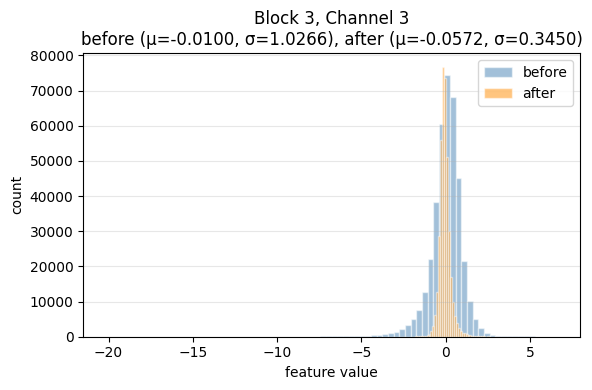

In [10]:
from src.film_analysis import analyze_film_per_channel
analyze_film_per_channel(
    feat_before = feat_before,
    feat_after  = feat_after,
    exp_name    = cfg["name"],
    out_dir     = out_dir,
    max_channels = 4,   # e.g. first 4 channels
)


[FiLM per-sample] Block 0 — exp12_film_fusion_EfficientNetB1_ExternalModulation_FreezeBackbone
  feat_before shape: (1982, 128, 14, 14)
  feat_after  shape: (1982, 128, 14, 14)


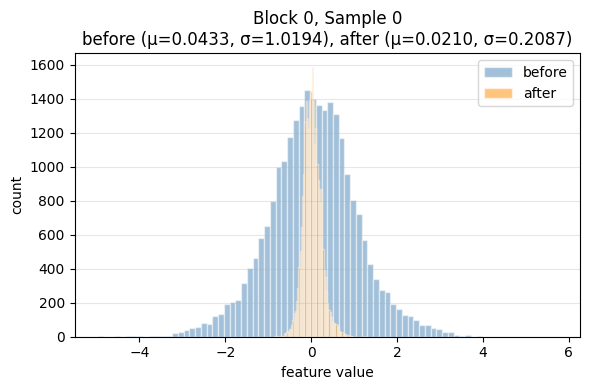

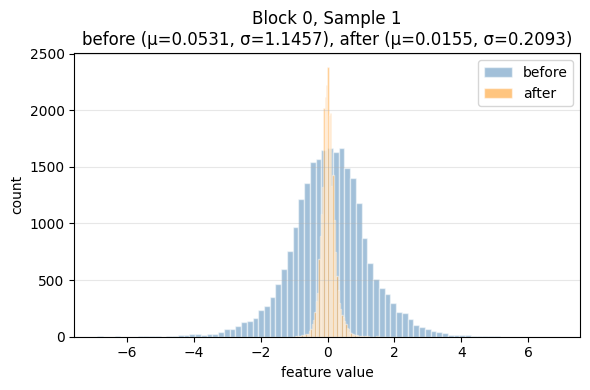

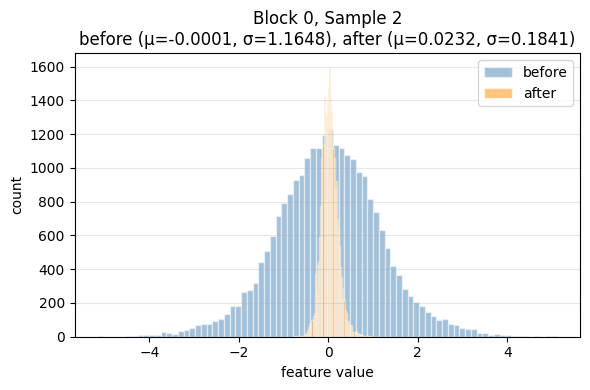

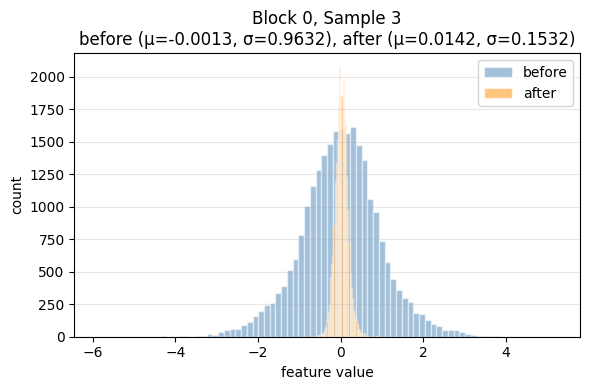


[FiLM per-sample] Block 1 — exp12_film_fusion_EfficientNetB1_ExternalModulation_FreezeBackbone
  feat_before shape: (1982, 128, 14, 14)
  feat_after  shape: (1982, 128, 14, 14)


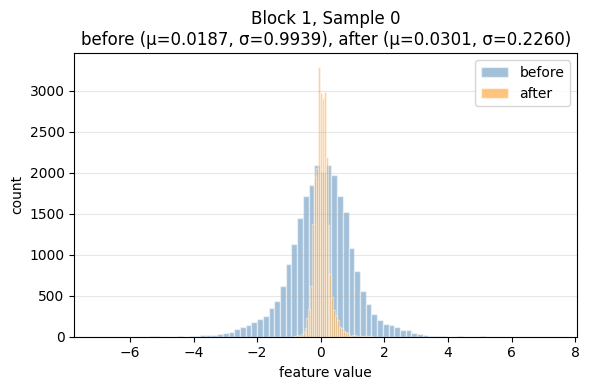

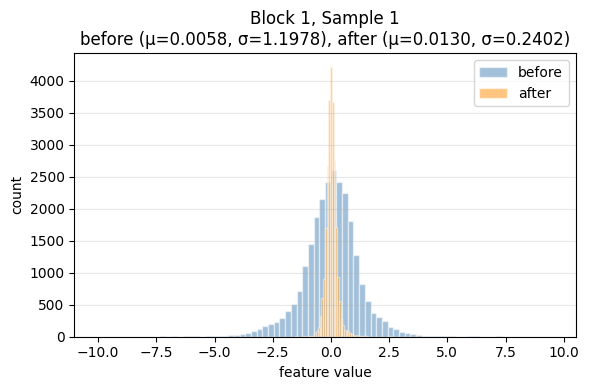

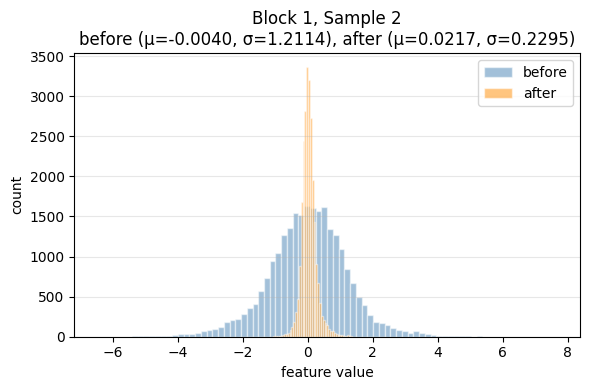

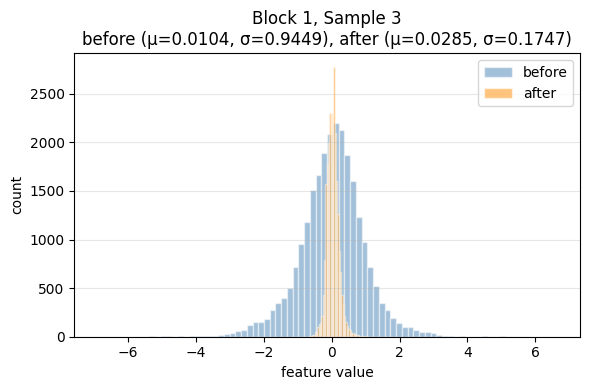


[FiLM per-sample] Block 2 — exp12_film_fusion_EfficientNetB1_ExternalModulation_FreezeBackbone
  feat_before shape: (1982, 128, 14, 14)
  feat_after  shape: (1982, 128, 14, 14)


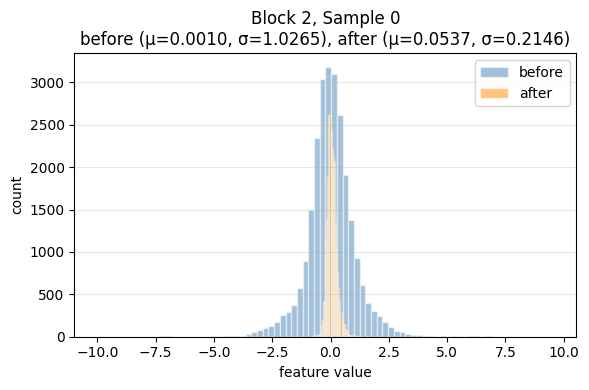

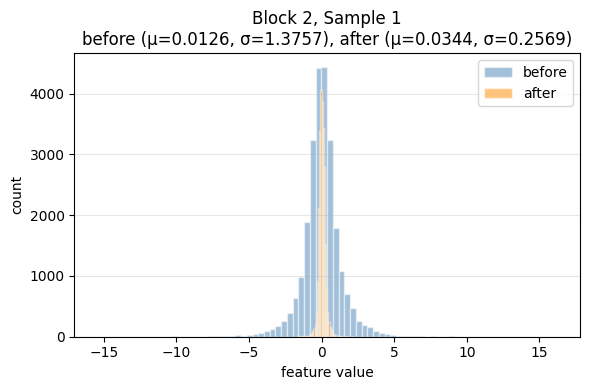

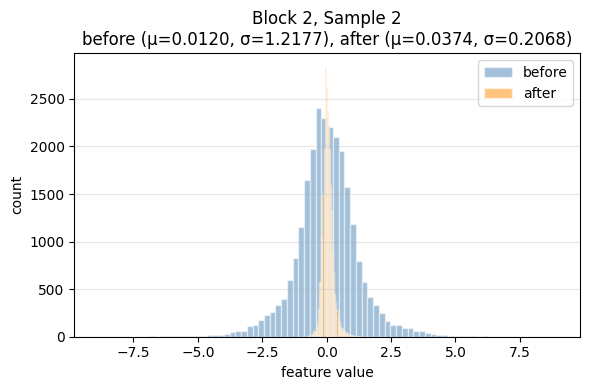

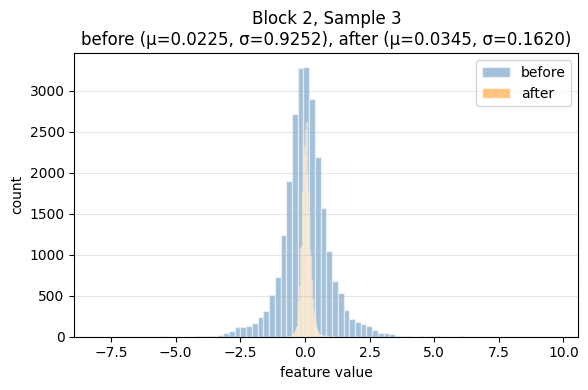


[FiLM per-sample] Block 3 — exp12_film_fusion_EfficientNetB1_ExternalModulation_FreezeBackbone
  feat_before shape: (1982, 128, 14, 14)
  feat_after  shape: (1982, 128, 14, 14)


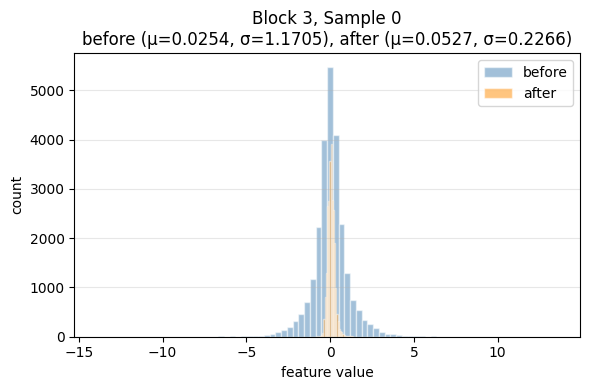

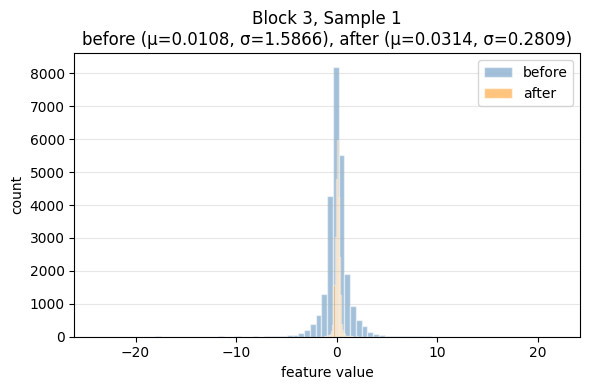

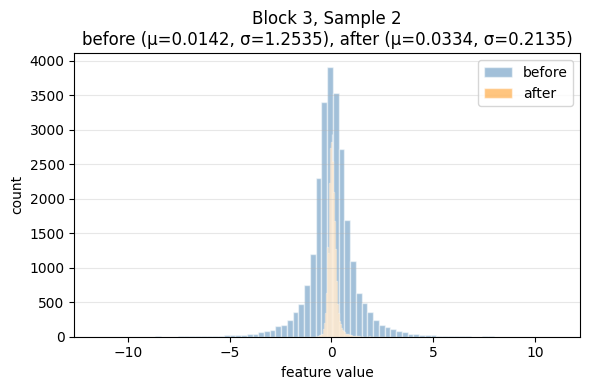

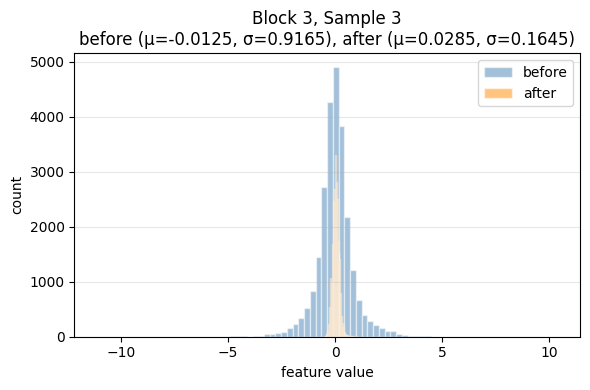

In [11]:
from src.film_analysis import analyze_film_per_sample
analyze_film_per_sample(
    feat_before = feat_before,
    feat_after  = feat_after,
    exp_name    = cfg["name"],
    out_dir     = out_dir,
    max_samples = 4,   # e.g. first 4 samples
)